# 第11章 深度学习处理文本

## 11.1 自然语言处理概述

Transformer 模型取代了 RNN

## 11.2 准备文本数据

文本**向量化**是指将文本转换为数值张量的过程。过程是：
- 首先，将文本**标准化**，使其更容易处理，比如转换为小写字母或删除标点符号。
- 然后，将文本拆分为单元 [ 称为**词元**（token）]，比如字符、单词或词组。这一步叫作**词元化**
- 最后，将每个词元转换为一个数值向量。这里通常需要首先对数据中的所有词元**建立索引**

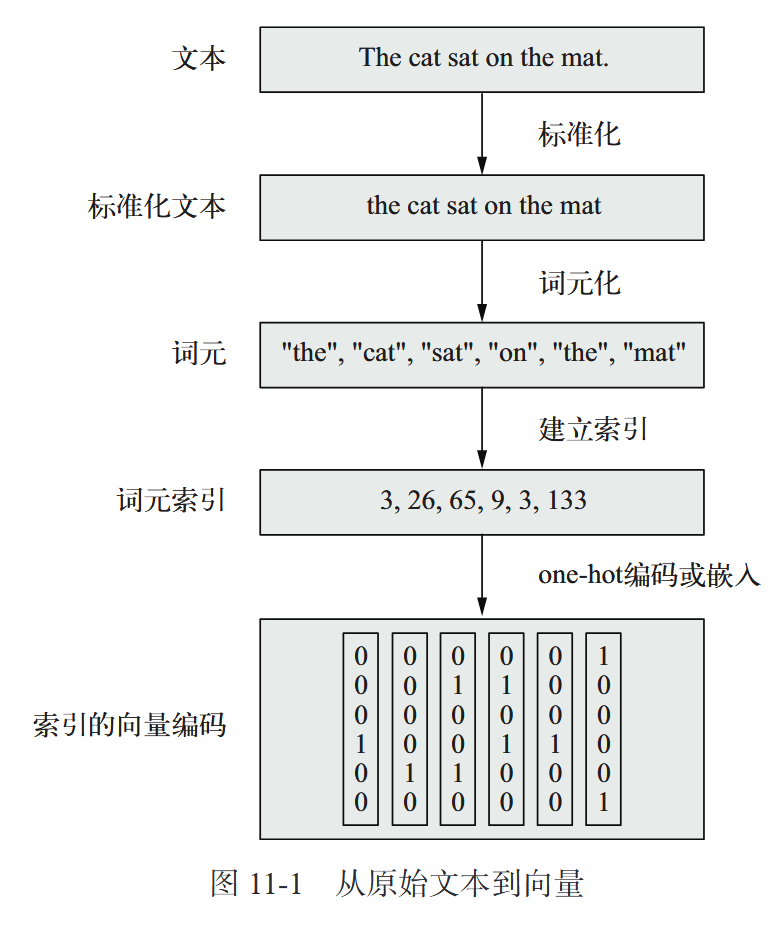

### 11.2.1 文本标准化

还 有 一 种 更 高 级 的 标 准 化 方 法, 但 在 机 器 学 习 中 很 少 使 用, 它 就 是 词 干 提 取  (stemming):将一个词的变体(比如动词的不同变位)转换为相同的表示,比如将“caught”  和“been catching”转换为“[catch]” 。使用这些标准化方法之后,模型将需要更少的训练数据,并且具有更好的泛化效果。

### 11.2.2 文本拆分（词元化）

完成文本标准化之后，需要将文本拆分为能够向量化的单元（词元），这一步叫作**词元化**。有 3 种方法：
- **单词级词元化**（word-level tokenization）
- **N 元语法词元化**（N-gram tokenization）
- **字符级词元化**（character-level tokenization）

### 11.2.3 建立词表索引

在建立索引的时候可以限制训练数据种前 20000 或 30000 个最常出现的单词。对罕见词建立索引会导致特征空间过大，其中大部分特征几乎没有信息量。

### 11.2.4 使用 `TextVectorization` 层

`TextVectorization` 层的文本标准化方法是“转换为小写字母并删除标点符号”,词元化方法是“利用空格进行拆分”。
`TextVectorization` 还支持自定义函数进行标准化和词元化。

## 11.3 表示单词组的两种方法：集合和序列

### 11.3.1 准备 IMDB 影评数据

In [ ]:
!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz
!rm -r aclImdb/train/unsup

将 20% 的训练文本文件放入一个新目录中，即 `aclImdb/val`

In [2]:
import os, pathlib, shutil, random
from tensorflow import keras
batch_size = 32
base_dir = pathlib.Path("aclImdb")
val_dir = base_dir / "val"
train_dir = base_dir / "train"
for category in ("neg", "pos"):
    os.makedirs(val_dir / category)
    files = os.listdir(train_dir / category)
    random.Random(1337).shuffle(files)
    num_val_samples = int(0.2 * len(files))
    val_files = files[-num_val_samples:]
    for fname in val_files:
        shutil.move(train_dir / category / fname,
                    val_dir / category / fname)

2025-02-20 09:47:50.923661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740016070.993429   12656 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740016071.013297   12656 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-20 09:47:51.183885: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


FileExistsError: [Errno 17] File exists: 'aclImdb/val/neg'

为训练、验证和测试创建 3 个 Dataset 对象

In [6]:
train_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/train", batch_size=batch_size
)
val_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/val", batch_size=batch_size
)
test_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/test", batch_size=batch_size
)
text_only_train_dsb = train_ds.map(lambda x, y: x)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


> `keras.utils.text_dataset_from_directory` 从一个路径下面读取文本文件，并根据路径下的文件目录生成 `tf.data.Dataset` 对象。
>
> `tf.data.Dataset` 类用于存储 `feature` 和 `targets` 数据。

代码清单 11-2 现实第一个批量的形状和数据类型

In [4]:
for inputs, targets in train_ds:
    print("inputs.shape:", inputs.shape) 
    print("inputs.dtype:", inputs.dtype) 
    print("targets.shape:", targets.shape) 
    print("targets.dtype:", targets.dtype) 
    print("inputs[0]:", inputs[0]) 
    print("targets[0]:", targets[0]) 
    break 

inputs.shape: (32,)
inputs.dtype: <dtype: 'string'>
targets.shape: (32,)
targets.dtype: <dtype: 'int32'>
inputs[0]: tf.Tensor(b'If this movie should be renamed, it should be "The Jackasses of Hazzard." To sum it up, this movie is nothing but 88 minutes of two immature country punks joyriding the famed 1968 Dodge Charger around town and in the country, chasing the girls and eluding the law.<br /><br />I have been a fan of the "Dukes" and what tarnishes the movie is the characters are out of key. The overindulgence of profanity, sexual references, and drug use, has made the good name of the "Dukes" into trailer trash.<br /><br />Side from comparing it to the television show, the acting was horrible. The only actor that got it right was the famed 1969 Dodge Charger named General Lee. The others have exaggerated the character\'s role which tarnished the movie.<br /><br />The "Dukes" have been another casualty of the 21-st century Hollywood television-to-big screen transition tragedy. Skip 

In [13]:
targets

<tf.Tensor: shape=(32,), dtype=int32, numpy=
array([0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1], dtype=int32)>

### 11.3.2 将单词作为集合处理：词袋方法

### 11.3.3 将单词作为序列处理：序列模型方法

#### 1. 第一个实例

代码清单 11-12 准备证书序列数据集

In [14]:
from tensorflow.keras import layers

max_length = 600
max_tokens = 20000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length,
)
text_vectorization.adapt(text_only_train_ds)

int_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)

2025-02-20 10:07:27.331936: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


代码清单 11-13 构建于 one_hot 编码的向量序列之上的序列模型

In [18]:
import tensorflow as tf
max_tokens = 20000
inputs = keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens, output_dim=64)(inputs)
x = layers.Bidirectional(layers.LSTM(32))(embedded)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 64)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,304,897 (4.98 MB)

 Trainable params: 1,304,897 (4.98 MB)

 Non-trainable params: 0 (0.00 B)